# Sensor Modality and Walkability Dimension Co-occurrence Analysis

In [1]:
import json
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from scipy.stats import chi2_contingency
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import scipy.cluster.hierarchy as sch
from sklearn.manifold import MDS
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_distances

# Set display options
pd.set_option("display.max_colwidth", 100)
sns.set(style="whitegrid")
# Set label font sizes
plt.rcParams.update({"axes.labelsize": 14})
plt.rcParams.update({"xtick.labelsize": 12})
plt.rcParams.update({"font.family": "Times New Roman"})

MATTE_COLORS = {
    'blue': '#4f9dc4',
    'red': '#e9785a',
    'teal': '#8ed165',
    'navy': '#3b3d3f',
    'gold': '#f2d156',
    'text': '#333333',       # Dark text color
    'pink': '#d97eb8',
    'purple': '#9478d5',
    'grid': '#dddddd',       # Light grid lines
    'background': '#f7f7f7'
}


def plot_label_combinations(memberships, title, top_n=15):
    """Combination-frequency plot: bar chart of counts plus membership matrix."""
    combo_counts = Counter(tuple(sorted(m)) for m in memberships if len(m) > 0)
    top_combos = combo_counts.most_common(top_n)
    categories = sorted({c for combo, _ in top_combos for c in combo})

    n_combos = len(top_combos)
    n_cats = len(categories)
    fig = plt.figure(figsize=(max(9, n_combos * 0.6), 3.5 + n_cats * 0.35))
    gs = fig.add_gridspec(2, 1, height_ratios=[2.2, n_cats * 0.35], hspace=0.05)
    ax_bar = fig.add_subplot(gs[0])
    ax_dots = fig.add_subplot(gs[1], sharex=ax_bar)

    counts = [c for _, c in top_combos]
    ax_bar.bar(range(n_combos), counts, color=MATTE_COLORS["blue"],
               edgecolor=MATTE_COLORS["navy"], linewidth=1.5)
    for i, c in enumerate(counts):
        ax_bar.text(i, c + max(counts) * 0.01, str(c), ha="center", va="bottom", fontsize=9)
    ax_bar.set_ylabel("Number of Articles")
    ax_bar.set_xticks([])
    ax_bar.set_title(title, fontsize=14, pad=20)
    ax_bar.spines[["top", "right"]].set_visible(False)

    for i, (combo, _) in enumerate(top_combos):
        for j, cat in enumerate(categories):
            filled = cat in combo
            ax_dots.plot(i, j, "o", color=MATTE_COLORS["navy"] if filled else MATTE_COLORS["grid"],
                         markersize=8)
        member_idx = [categories.index(c) for c in combo]
        if len(member_idx) > 1:
            ax_dots.plot([i] * len(member_idx), member_idx, color=MATTE_COLORS["navy"],
                         linewidth=1.5, zorder=0)

    ax_dots.set_yticks(range(n_cats))
    ax_dots.set_yticklabels(categories)
    ax_dots.set_xlim(-0.5, n_combos - 0.5)
    ax_dots.set_ylim(-0.5, n_cats - 0.5)
    ax_dots.invert_yaxis()
    ax_dots.set_xticks([])
    for spine in ax_dots.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()

# 1. Load Dataset

In [ ]:
df = pd.read_json("../data/06_2_classified_sensor_types_v5.json")
df["macro_dimensions"] = df["macro_dimensions"].apply(lambda x: x if isinstance(x, list) else [])
df["macro_sensor_types"] = df["macro_sensor_types"].apply(lambda x: x if isinstance(x, list) else [])

print(f"Loaded {len(df)} articles")
print(f"Articles with at least one sensor category: {(df['macro_sensor_types'].str.len() > 0).sum()}")

Loaded 610 articles
Articles with at least one sensor category: 610


# 2. Documents per Year

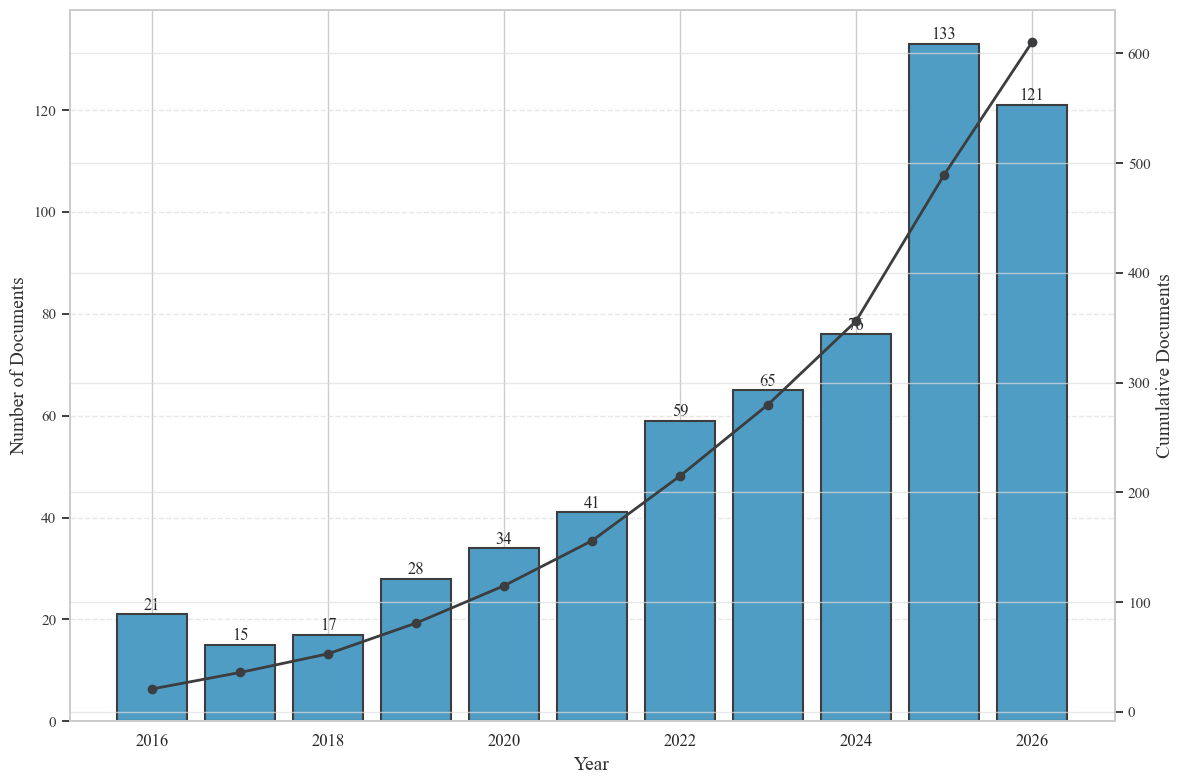

Total documents: 610
Documents with year information: 610
Earliest publication year: 2016
Latest publication year: 2026
Year with most publications: 2025 (133 documents)


In [3]:
years = [d for d in df["publication_date"] if d]
year_counts = Counter(years)

df_years = pd.DataFrame(list(year_counts.items()), columns=["Year", "Count"])
df_years = df_years.sort_values("Year")

fig, ax1 = plt.subplots(figsize=(12, 8))
ax2 = ax1.twinx()

bars = ax1.bar(df_years["Year"], df_years["Count"], color=MATTE_COLORS['blue'],
               edgecolor=MATTE_COLORS['navy'], linewidth=1.5)
ax1.set_xlabel("Year", fontsize=14, color=MATTE_COLORS['text'])
ax1.set_ylabel("Number of Documents", fontsize=14, color=MATTE_COLORS['text'])
ax1.tick_params(axis="y", labelcolor=MATTE_COLORS['text'])

df_years["Cumulative"] = df_years["Count"].cumsum()
line = ax2.plot(df_years["Year"], df_years["Cumulative"], marker="o",
                color=MATTE_COLORS['navy'], linewidth=2)
ax2.set_ylabel("Cumulative Documents", fontsize=14, color=MATTE_COLORS['text'])
ax2.tick_params(axis="y", labelcolor=MATTE_COLORS['text'])

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f"{height:.0f}", ha="center", va="bottom")

ax1.grid(axis="y", linestyle="--", alpha=0.7, color=MATTE_COLORS['grid'])
ax2.grid(axis="y", linestyle="-", alpha=0.7, color=MATTE_COLORS['grid'])

plt.tight_layout()
plt.show()

print(f"Total documents: {len(df)}")
print(f"Documents with year information: {len(years)}")
print(f"Earliest publication year: {min(years)}")
print(f"Latest publication year: {max(years)}")
print(f"Year with most publications: {year_counts.most_common(1)[0][0]} ({year_counts.most_common(1)[0][1]} documents)")

# 3. Articles per Document Type

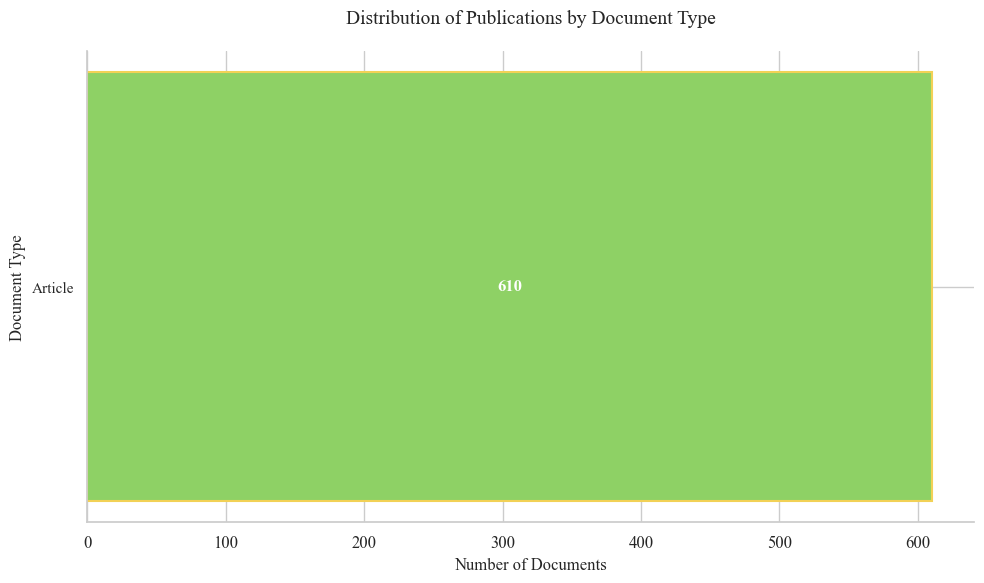

In [4]:
doc_types = []
for _, doc in df.iterrows():
    if doc.get("document_type") and "RETRACTED" not in str(doc.get("title", "")).upper():
        doc_type = doc["document_type"]
        if doc_type in ["Article", "Conference Paper"]:
            doc_types.append(doc_type)
        else:
            doc_types.append("Others")

doc_type_counts = Counter(doc_types)

df_doc_types = pd.DataFrame(
    list(doc_type_counts.items()), columns=["Document Type", "Count"]
).sort_values("Count", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_doc_types["Document Type"], df_doc_types["Count"],
    color=MATTE_COLORS['teal'], edgecolor=MATTE_COLORS['gold'], linewidth=1.5
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width / 2,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        ha="center", va="center", color="white", fontweight="bold",
    )

ax.set_xlabel("Number of Documents", fontsize=12)
ax.set_ylabel("Document Type", fontsize=12)
ax.set_title("Distribution of Publications by Document Type", fontsize=14, pad=20)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# 4. Subject Areas

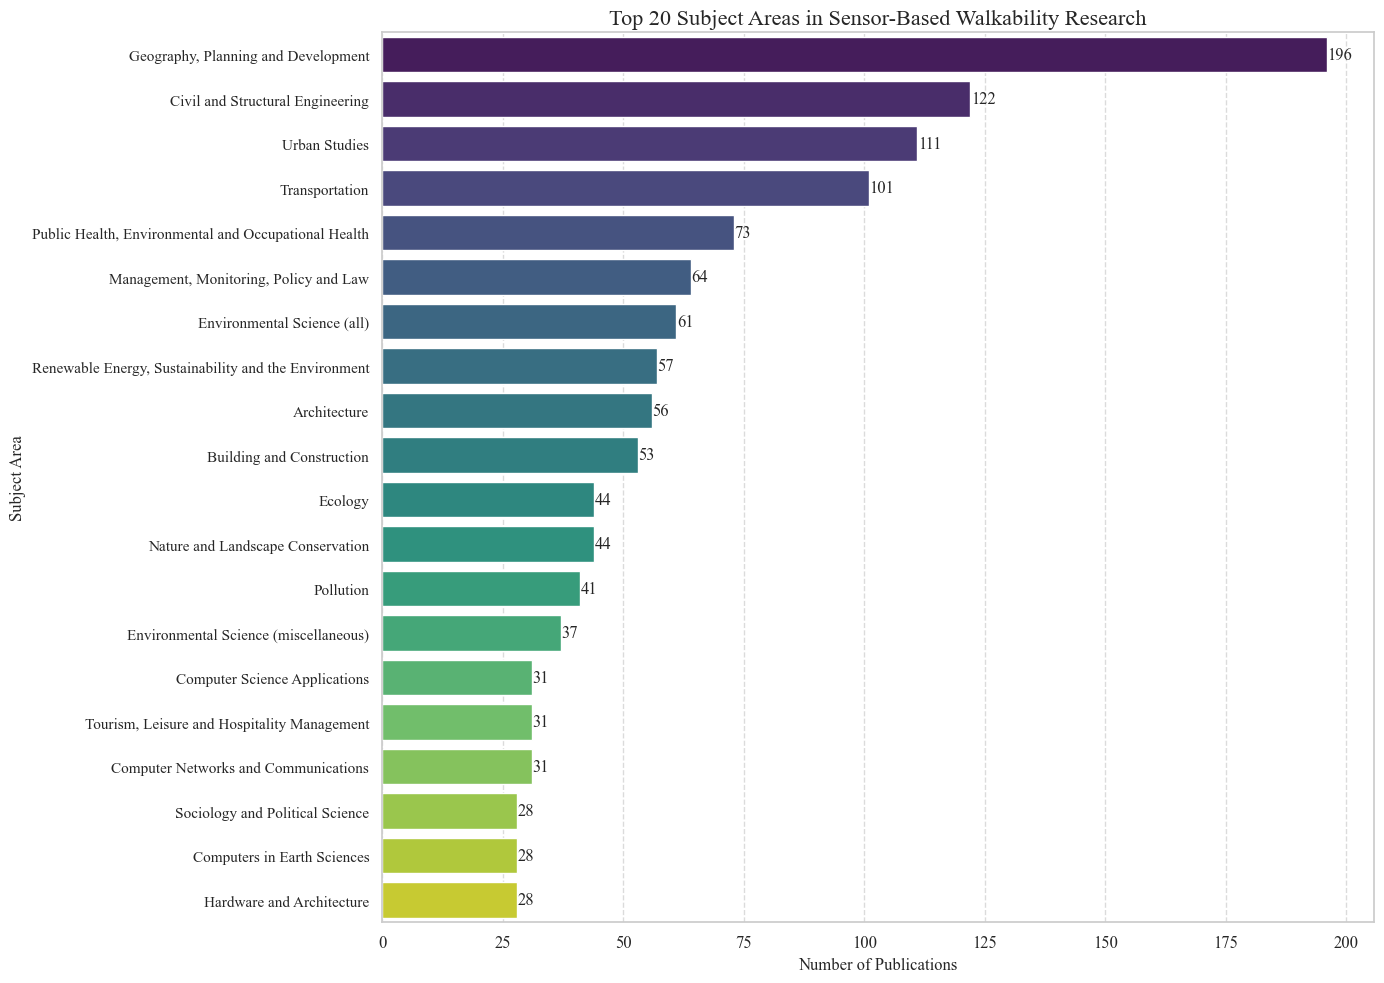



Performing correlation analysis between subject areas...


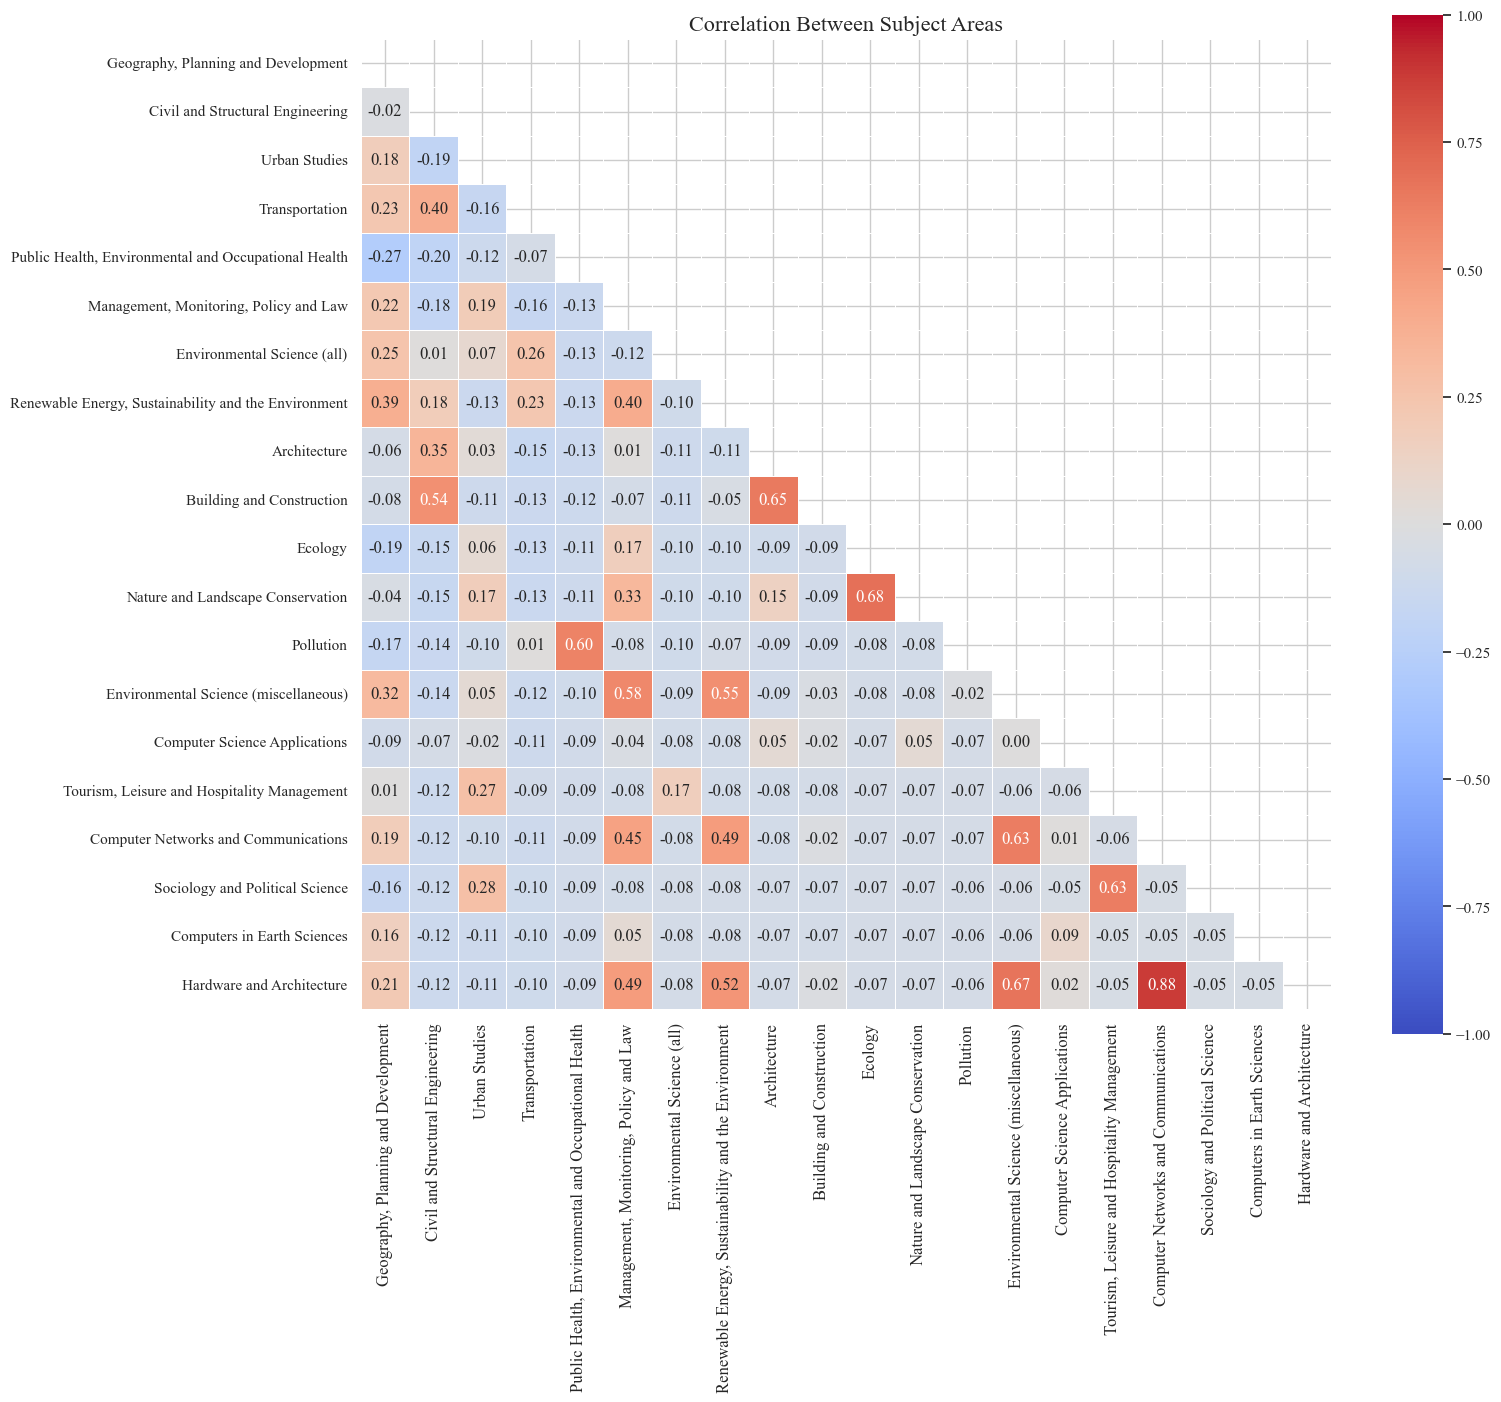


Subject Area Analysis Summary:
Total unique subject areas: 142
Documents with subject area information: 575 out of 610
Average subject areas per document: 3.42

Top 5 most common subject area pairs:
58 - Geography, Planning and Development & Transportation
57 - Geography, Planning and Development & Urban Studies
57 - Civil and Structural Engineering & Transportation
51 - Geography, Planning and Development & Renewable Energy, Sustainability and the Environment
48 - Building and Construction & Civil and Structural Engineering


In [5]:
all_subject_areas = []
subject_area_by_doc = {}

for i, doc in df.reset_index(drop=True).iterrows():
    areas = doc.get("subject_areas")
    if isinstance(areas, list) and areas:
        subject_area_by_doc[i] = areas
        all_subject_areas.extend(areas)

subject_counts = Counter(all_subject_areas)
top_subject_areas = subject_counts.most_common(20)
df_subjects = pd.DataFrame(top_subject_areas, columns=["Subject Area", "Count"])

plt.figure(figsize=(14, 10))
ax = sns.barplot(
    x="Count", y="Subject Area", hue="Subject Area",
    data=df_subjects, palette="viridis", legend=False
)
plt.title("Top 20 Subject Areas in Sensor-Based Walkability Research", fontsize=16)
plt.xlabel("Number of Publications", fontsize=12)
plt.ylabel("Subject Area", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

for i, v in enumerate(df_subjects["Count"]):
    ax.text(v + 0.1, i, str(v), va="center")

plt.tight_layout()
plt.show()

print("\n\nPerforming correlation analysis between subject areas...")

unique_areas = [area for area, _ in top_subject_areas]
doc_subject_matrix = pd.DataFrame(0, index=range(len(subject_area_by_doc)), columns=unique_areas)

for pos, (doc_idx, areas) in enumerate(subject_area_by_doc.items()):
    for area in areas:
        if area in unique_areas:
            doc_subject_matrix.loc[pos, area] = 1

correlation_matrix = doc_subject_matrix.corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f",
    mask=mask, vmin=-1, vmax=1, square=True, linewidths=0.5,
)
plt.title("Correlation Between Subject Areas", fontsize=16)
plt.tight_layout()
plt.show()

print("\nSubject Area Analysis Summary:")
print(f"Total unique subject areas: {len(subject_counts)}")
print(f"Documents with subject area information: {len(subject_area_by_doc)} out of {len(df)}")

areas_per_doc = [len(areas) for areas in subject_area_by_doc.values()]
print(f"Average subject areas per document: {sum(areas_per_doc)/len(areas_per_doc):.2f}")

print("\nTop 5 most common subject area pairs:")
pair_counts = Counter()
for areas in subject_area_by_doc.values():
    for pair in combinations(sorted(areas), 2):
        pair_counts[pair] += 1

for pair, count in pair_counts.most_common(5):
    print(f"{count:2d} - {pair[0]} & {pair[1]}")

# 5. Sensing Modality Distribution

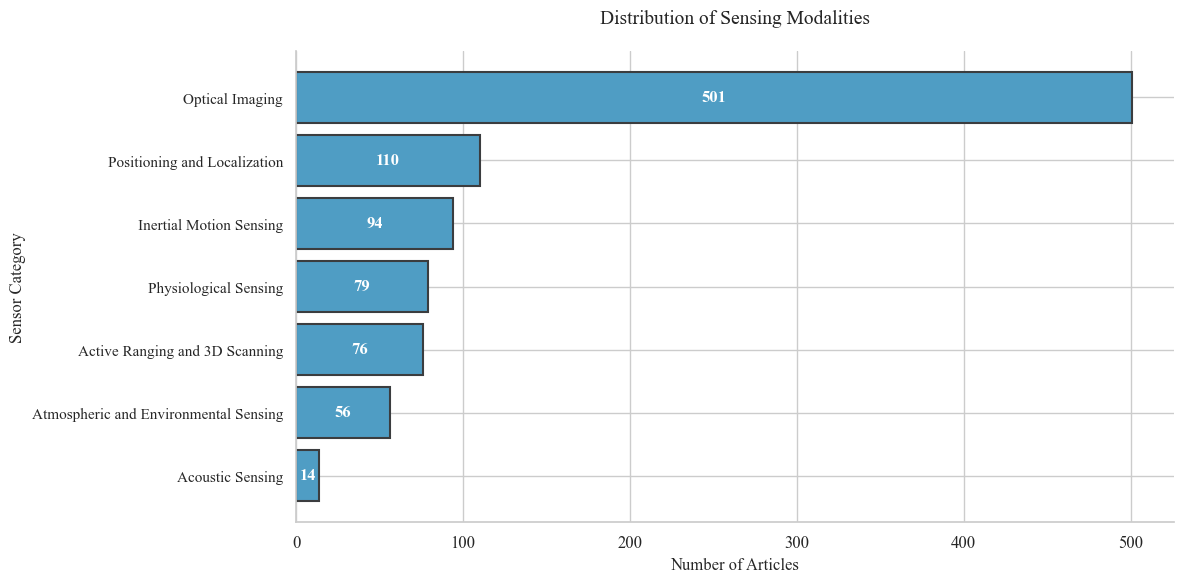

In [6]:
sensor_counts = Counter()
for categories in df["macro_sensor_types"]:
    sensor_counts.update(categories)

df_sensors = pd.DataFrame(sensor_counts.most_common(), columns=["Sensor Category", "Count"])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(df_sensors["Sensor Category"][::-1], df_sensors["Count"][::-1],
                color=MATTE_COLORS['blue'], edgecolor=MATTE_COLORS['navy'], linewidth=1.5)
for bar in bars:
    width = bar.get_width()
    ax.text(width / 2, bar.get_y() + bar.get_height() / 2, f"{int(width):,}",
            ha="center", va="center", color="white", fontweight="bold")
ax.set_xlabel("Number of Articles", fontsize=12)
ax.set_ylabel("Sensor Category", fontsize=12)
ax.set_title("Distribution of Sensing Modalities", fontsize=14, pad=20)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# 6. Walkability Dimension Distribution

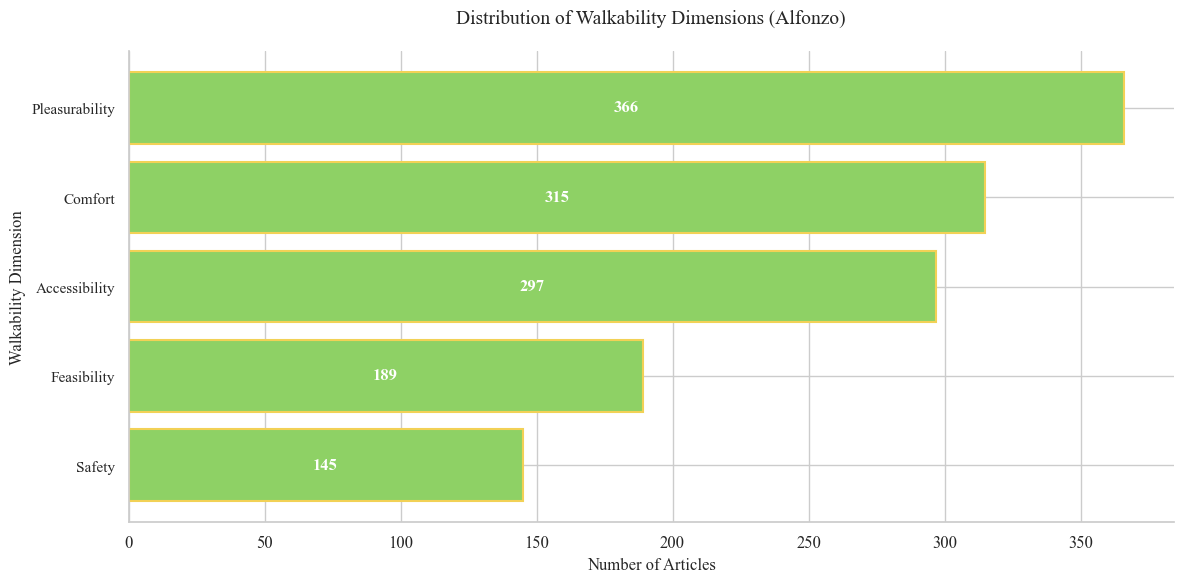

In [7]:
dimension_counts = Counter()
for dimensions in df["macro_dimensions"]:
    dimension_counts.update(dimensions)

df_dimensions = pd.DataFrame(dimension_counts.most_common(), columns=["Dimension", "Count"])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(df_dimensions["Dimension"][::-1], df_dimensions["Count"][::-1],
                color=MATTE_COLORS['teal'], edgecolor=MATTE_COLORS['gold'], linewidth=1.5)
for bar in bars:
    width = bar.get_width()
    ax.text(width / 2, bar.get_y() + bar.get_height() / 2, f"{int(width):,}",
            ha="center", va="center", color="white", fontweight="bold")
ax.set_xlabel("Number of Articles", fontsize=12)
ax.set_ylabel("Walkability Dimension", fontsize=12)
ax.set_title("Distribution of Walkability Dimensions (Alfonzo)", fontsize=14, pad=20)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# 7. Label Combination Frequency

C:\Users\vinic\AppData\Local\Temp\ipykernel_18516\555226468.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


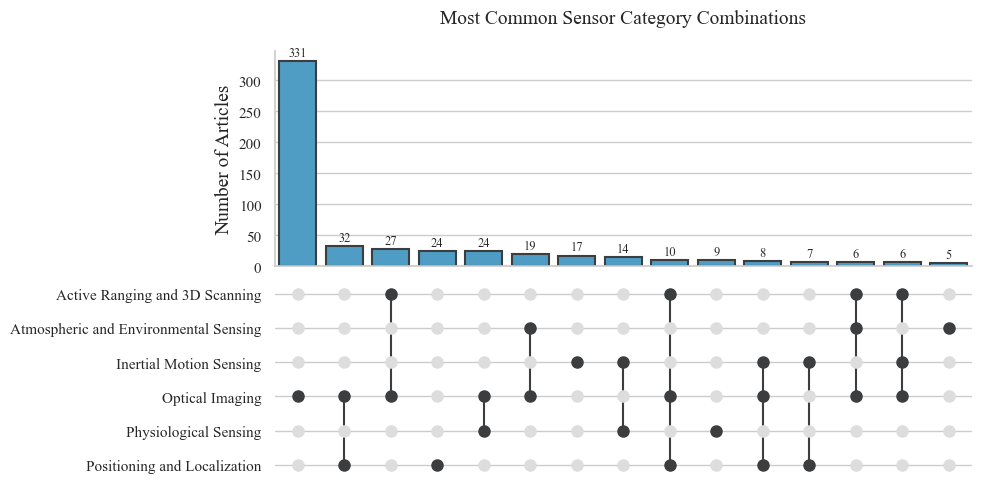

In [8]:
plot_label_combinations(df["macro_sensor_types"], "Most Common Sensor Category Combinations")

C:\Users\vinic\AppData\Local\Temp\ipykernel_18516\555226468.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


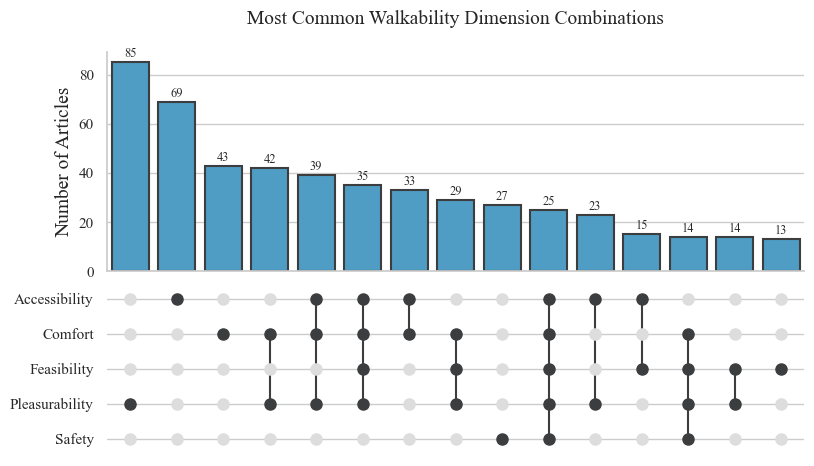

In [9]:
plot_label_combinations(df["macro_dimensions"], "Most Common Walkability Dimension Combinations")

# 8. Sensor x Dimension Cross-Tabulation

In [10]:
pairs = []
for _, row in df.iterrows():
    for sensor in row["macro_sensor_types"]:
        for dimension in row["macro_dimensions"]:
            pairs.append({"sensor": sensor, "dimension": dimension})

pairs_df = pd.DataFrame(pairs)
crosstab_counts = pd.crosstab(pairs_df["sensor"], pairs_df["dimension"])
crosstab_row_pct = pd.crosstab(pairs_df["sensor"], pairs_df["dimension"], normalize="index") * 100

n_with_both = (df["macro_sensor_types"].str.len() > 0) & (df["macro_dimensions"].str.len() > 0)
print(f"Articles contributing to the cross-tabulation (sensor and dimension both assigned): {n_with_both.sum()}")

crosstab_counts

Articles contributing to the cross-tabulation (sensor and dimension both assigned): 610


dimension,Accessibility,Comfort,Feasibility,Pleasurability,Safety
sensor,,,,,
Acoustic Sensing,4,9,3,7,3
Active Ranging and 3D Scanning,34,46,40,45,24
Atmospheric and Environmental Sensing,17,35,21,26,11
Inertial Motion Sensing,58,47,28,45,27
Optical Imaging,231,257,159,318,123
Physiological Sensing,34,46,25,53,20
Positioning and Localization,75,49,37,49,30


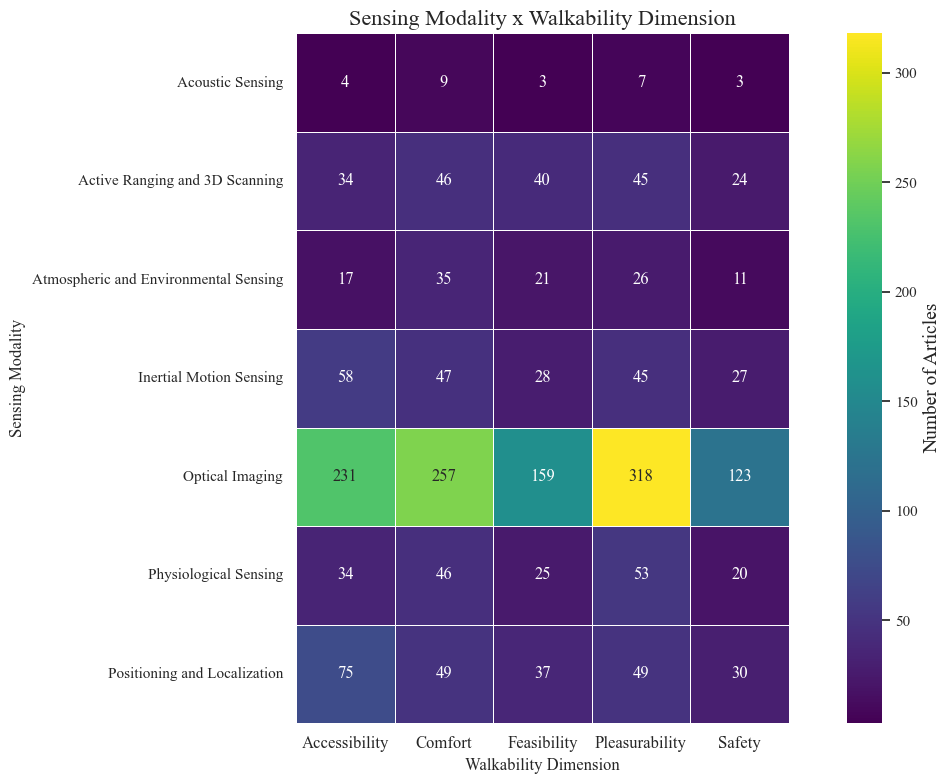

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(crosstab_counts, annot=True, fmt="d", cmap="viridis",
            linewidths=0.5, square=True,
            cbar_kws={"label": "Number of Articles"})
plt.title("Sensing Modality x Walkability Dimension", fontsize=16)
plt.xlabel("Walkability Dimension", fontsize=12)
plt.ylabel("Sensing Modality", fontsize=12)
plt.tight_layout()
plt.show()

# 9. Statistical Association: Chi-Square Test and Standardized Residuals

Chi-square statistic: 40.49
Degrees of freedom: 24
p-value: 0.01891


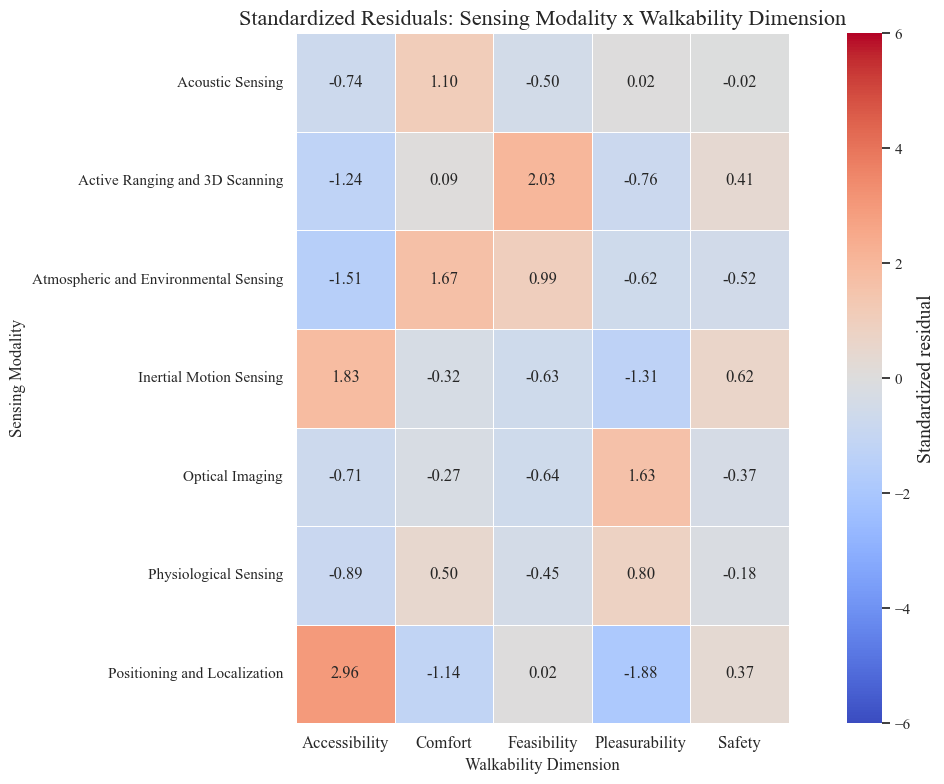


Cells with |standardized residual| > 2 (association stronger than expected under independence):
  - Active Ranging and 3D Scanning x Feasibility: 2.03 (over-represented)
  - Positioning and Localization x Accessibility: 2.96 (over-represented)


In [12]:
chi2, p_value, dof, expected = chi2_contingency(crosstab_counts)
expected_df = pd.DataFrame(expected, index=crosstab_counts.index, columns=crosstab_counts.columns)
standardized_residuals = (crosstab_counts - expected_df) / np.sqrt(expected_df)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4g}")

plt.figure(figsize=(12, 8))
sns.heatmap(
    standardized_residuals, annot=True, cmap="coolwarm", fmt=".2f",
    center=0, vmin=-6, vmax=6, square=True, linewidths=0.5,
    cbar_kws={"label": "Standardized residual"},
)
plt.title("Standardized Residuals: Sensing Modality x Walkability Dimension", fontsize=16)
plt.xlabel("Walkability Dimension", fontsize=12)
plt.ylabel("Sensing Modality", fontsize=12)
plt.tight_layout()
plt.show()

print("\nCells with |standardized residual| > 2 (association stronger than expected under independence):")
for sensor in standardized_residuals.index:
    for dimension in standardized_residuals.columns:
        value = standardized_residuals.loc[sensor, dimension]
        if abs(value) > 2:
            direction = "over-represented" if value > 0 else "under-represented"
            print(f"  - {sensor} x {dimension}: {value:.2f} ({direction})")

# 10. Article-Level Archetypes: Hierarchical Clustering
Categories are weighted by inverse document frequency before computing distance, so ubiquitous categories (e.g. Street-View, present in most articles) do not dominate the clustering and rarer, more distinguishing combinations can separate out.

In [13]:
archetype_df = df[(df["macro_sensor_types"].str.len() > 0) & (df["macro_dimensions"].str.len() > 0)].copy()
archetype_df = archetype_df.reset_index(drop=True)

sensor_dummies = pd.get_dummies(archetype_df["macro_sensor_types"].explode()).groupby(level=0).max()
dimension_dummies = pd.get_dummies(archetype_df["macro_dimensions"].explode()).groupby(level=0).max()
feature_matrix = pd.concat([sensor_dummies, dimension_dummies], axis=1).fillna(0).astype(int)

print(f"Articles included in archetype analysis: {len(feature_matrix)}")
print(f"Feature dimensions (sensor categories + walkability dimensions): {feature_matrix.shape[1]}")

# Inverse document frequency per category, so common categories contribute less to
# distance than rare, more discriminating ones.
n_articles = len(feature_matrix)
category_frequency = feature_matrix.sum(axis=0)
idf_weights = np.log((1 + n_articles) / (1 + category_frequency)) + 1
weighted_matrix = feature_matrix.values * idf_weights.values

distance_matrix = cosine_distances(weighted_matrix)
condensed_distance = squareform(distance_matrix, checks=False)
linkage_matrix = linkage(condensed_distance, method="average")

Articles included in archetype analysis: 610
Feature dimensions (sensor categories + walkability dimensions): 12


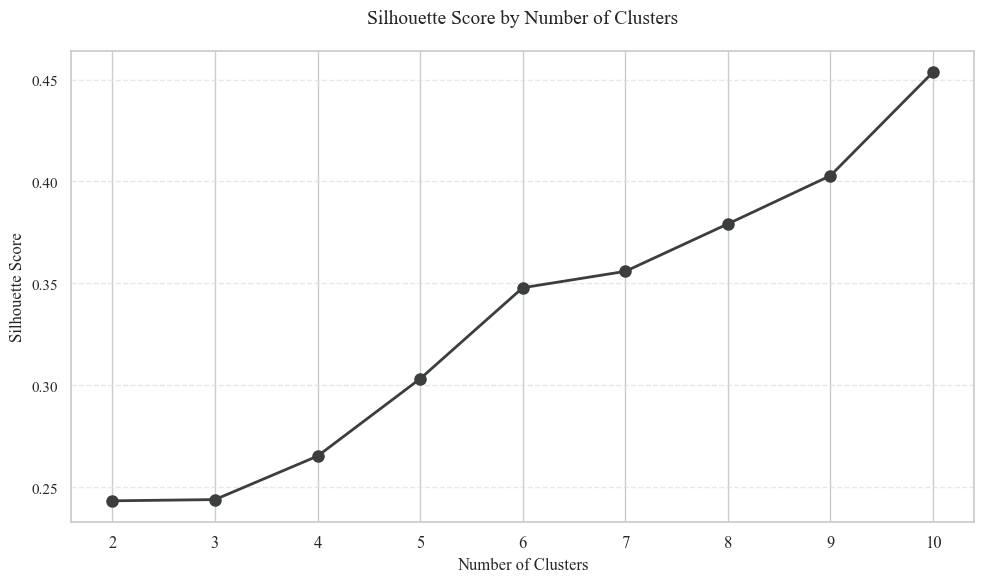

Selected number of clusters: 10 (silhouette score: 0.454)


In [14]:
silhouette_scores = {}
for k in range(2, 11):
    cluster_labels = fcluster(linkage_matrix, t=k, criterion="maxclust")
    if len(set(cluster_labels)) > 1:
        silhouette_scores[k] = silhouette_score(distance_matrix, cluster_labels, metric="precomputed")

plt.figure(figsize=(10, 6))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), "o-",
         color=MATTE_COLORS["navy"], linewidth=2, markersize=8)
plt.xlabel("Number of Clusters", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Silhouette Score by Number of Clusters", fontsize=14, pad=20)
plt.grid(axis="y", linestyle="--", alpha=0.7, color=MATTE_COLORS["grid"])
plt.tight_layout()
plt.show()

optimal_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"Selected number of clusters: {optimal_k} (silhouette score: {silhouette_scores[optimal_k]:.3f})")

cluster_labels = fcluster(linkage_matrix, t=optimal_k, criterion="maxclust") - 1
archetype_df["cluster"] = cluster_labels

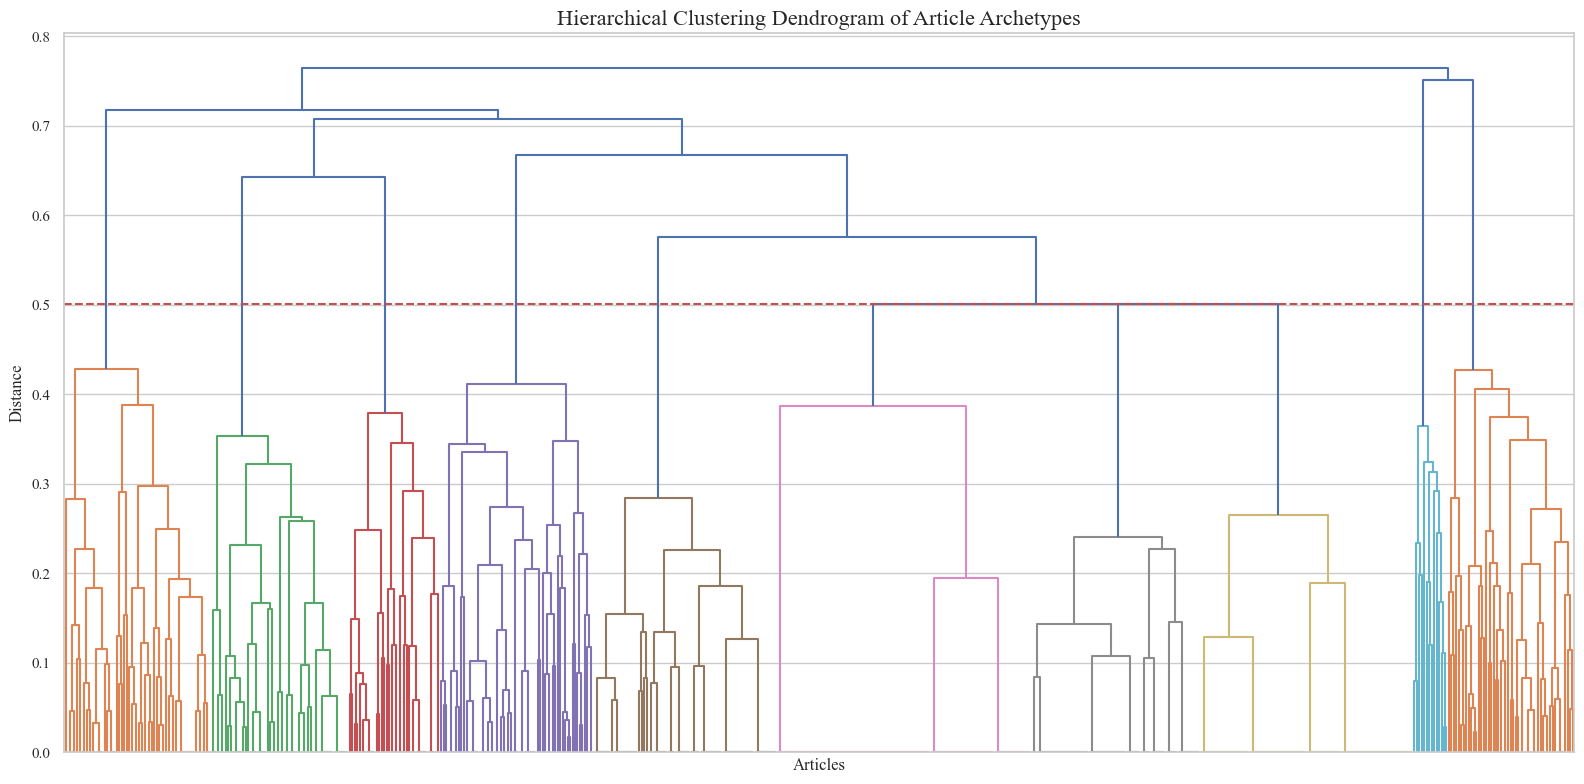

In [15]:
plt.figure(figsize=(16, 8))
dendro = sch.dendrogram(linkage_matrix, no_labels=True,
                         color_threshold=linkage_matrix[-(optimal_k - 1), 2])
plt.title("Hierarchical Clustering Dendrogram of Article Archetypes", fontsize=16)
plt.xlabel("Articles", fontsize=12)
plt.ylabel("Distance", fontsize=12)
plt.axhline(y=linkage_matrix[-(optimal_k - 1), 2], color="r", linestyle="--")
plt.tight_layout()
plt.show()

# 11. MDS Projection of Article Archetypes

C:\Users\vinic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


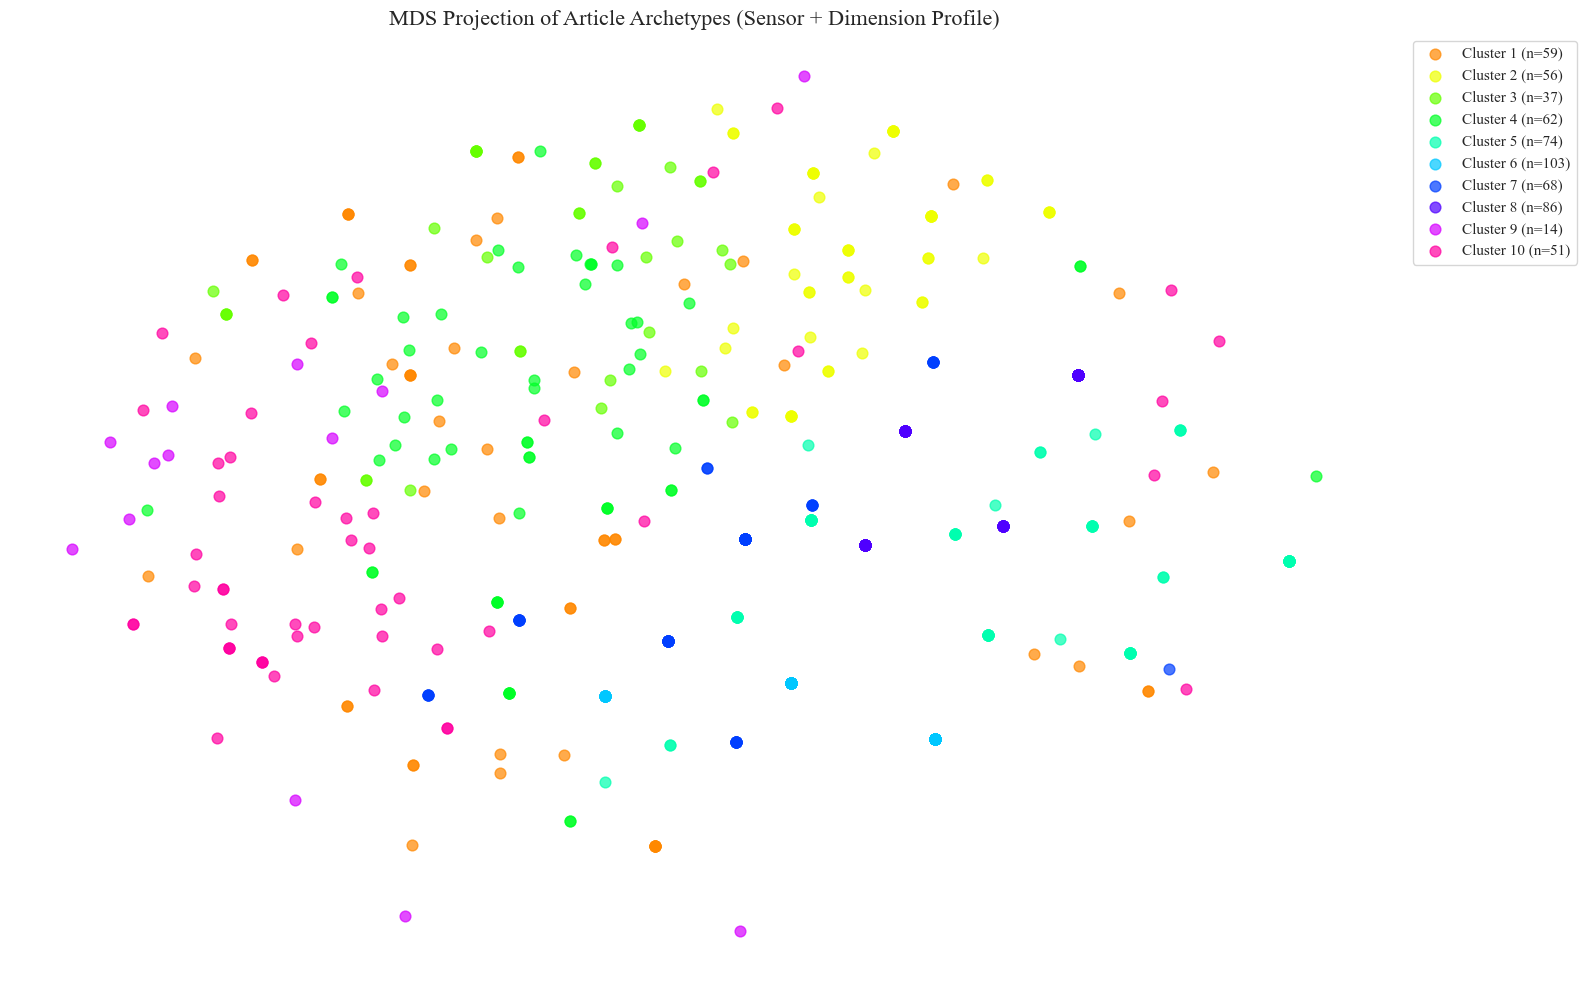

In [16]:
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42, normalized_stress="auto")
positions = mds.fit_transform(distance_matrix)

palette = sns.color_palette("hsv", optimal_k)

plt.figure(figsize=(16, 10))
for cluster_id in range(optimal_k):
    cluster_mask = cluster_labels == cluster_id
    plt.scatter(
        positions[cluster_mask, 0],
        positions[cluster_mask, 1],
        s=60,
        c=[palette[cluster_id]],
        label=f"Cluster {cluster_id + 1} (n={cluster_mask.sum()})",
        alpha=0.7,
    )

plt.title("MDS Projection of Article Archetypes (Sensor + Dimension Profile)", fontsize=16)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.axis("off")
plt.tight_layout()
plt.show()

# 12. Cluster Composition Summary

In [17]:
summary_rows = []
for cluster_id in range(optimal_k):
    cluster_data = archetype_df[archetype_df["cluster"] == cluster_id]

    sensor_counts_cluster = Counter()
    for categories in cluster_data["macro_sensor_types"]:
        sensor_counts_cluster.update(categories)

    dimension_counts_cluster = Counter()
    for dimensions in cluster_data["macro_dimensions"]:
        dimension_counts_cluster.update(dimensions)

    top_sensor = sensor_counts_cluster.most_common(1)[0][0] if sensor_counts_cluster else "-"
    top_dimension = dimension_counts_cluster.most_common(1)[0][0] if dimension_counts_cluster else "-"

    summary_rows.append({
        "Cluster": cluster_id + 1,
        "Size": len(cluster_data),
        "Dominant Sensor": top_sensor,
        "Dominant Dimension": top_dimension,
        "Top 3 Sensors": ", ".join(s for s, _ in sensor_counts_cluster.most_common(3)),
        "Top 3 Dimensions": ", ".join(d for d, _ in dimension_counts_cluster.most_common(3)),
    })

cluster_summary = pd.DataFrame(summary_rows).set_index("Cluster")
cluster_summary

,Size,Dominant Sensor,Dominant Dimension,Top 3 Sensors,Top 3 Dimensions
Cluster,,,,,
1,59,Physiological Sensing,Pleasurability,"Physiological Sensing, Optical Imaging, Inertial Motion Sensing","Pleasurability, Comfort, Accessibility"
2,56,Positioning and Localization,Accessibility,"Positioning and Localization, Optical Imaging","Accessibility, Comfort, Feasibility"
3,37,Inertial Motion Sensing,Accessibility,"Inertial Motion Sensing, Positioning and Localization, Optical Imaging","Accessibility, Comfort, Pleasurability"
4,62,Active Ranging and 3D Scanning,Pleasurability,"Active Ranging and 3D Scanning, Optical Imaging, Inertial Motion Sensing","Pleasurability, Comfort, Feasibility"
5,74,Optical Imaging,Safety,Optical Imaging,"Safety, Pleasurability, Comfort"
6,103,Optical Imaging,Pleasurability,Optical Imaging,"Pleasurability, Comfort"
7,68,Optical Imaging,Feasibility,Optical Imaging,"Feasibility, Pleasurability, Comfort"
8,86,Optical Imaging,Accessibility,Optical Imaging,"Accessibility, Comfort, Pleasurability"
9,14,Acoustic Sensing,Comfort,"Acoustic Sensing, Inertial Motion Sensing, Optical Imaging","Comfort, Pleasurability, Accessibility"


# 13. Author Keyword Analysis

Total unique keywords: 1851


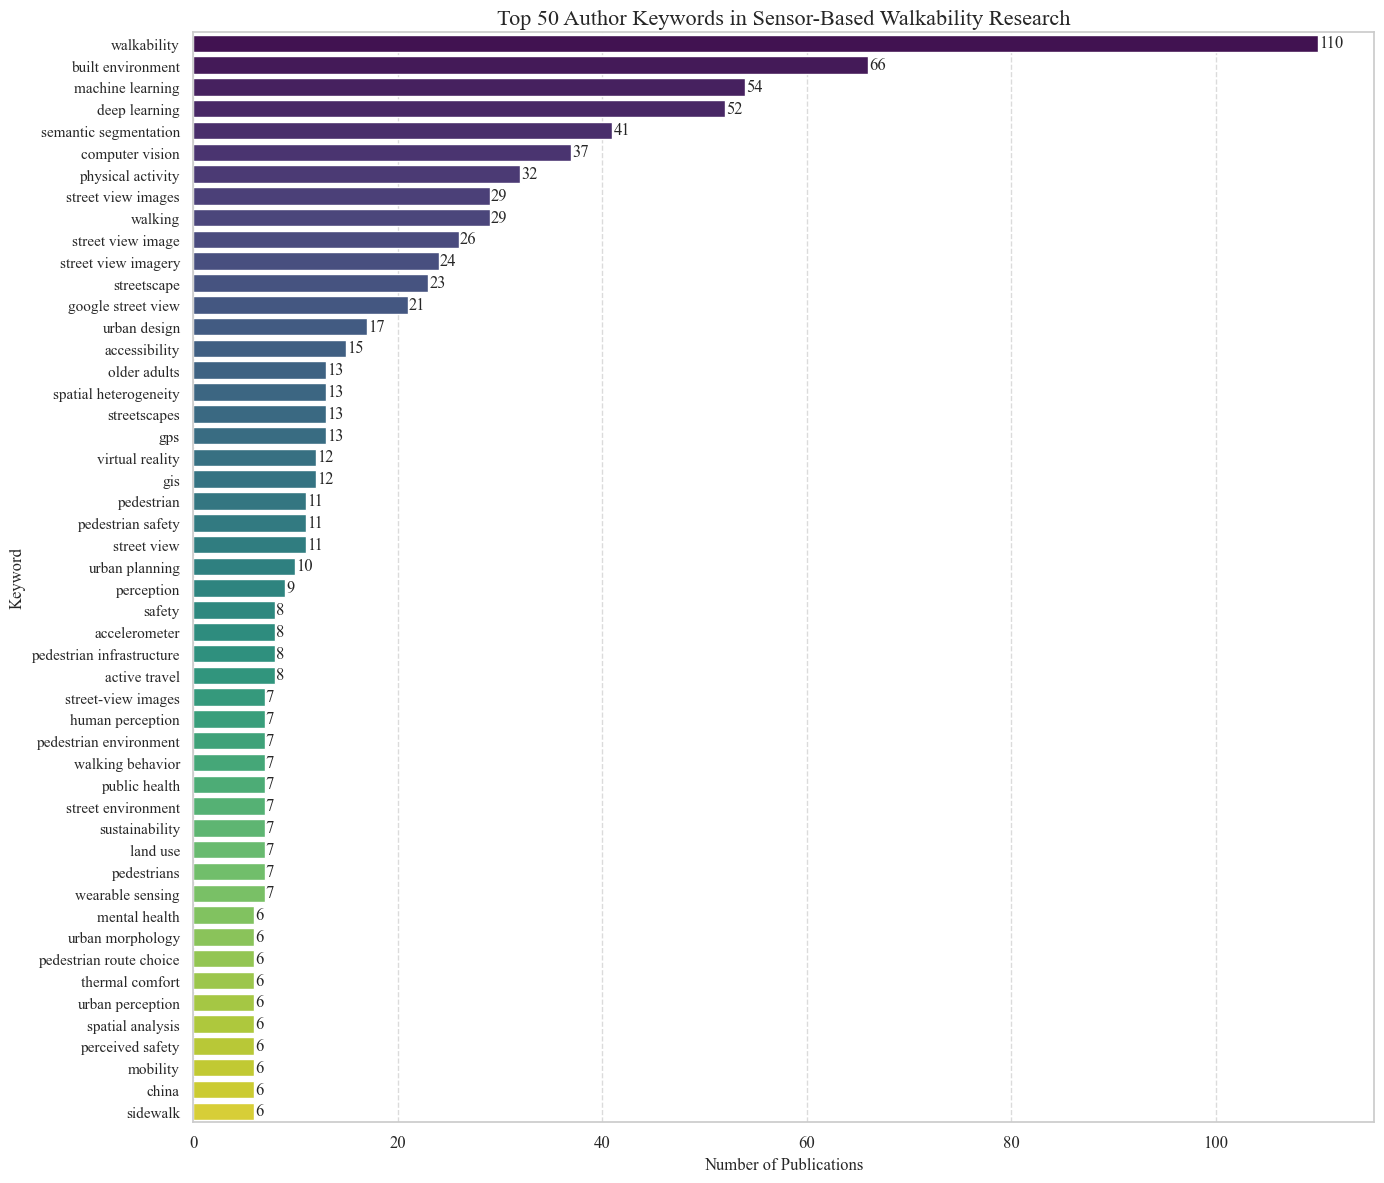

In [18]:
all_keywords = []
keywords_by_doc = {}
keyword_to_articles = {}

for i, doc in df.reset_index(drop=True).iterrows():
    kws = doc.get("author_keywords")
    if isinstance(kws, list) and kws:
        keywords = [kw.lower().strip() for kw in kws]
        keywords_by_doc[i] = keywords
        all_keywords.extend(keywords)
        for kw in keywords:
            keyword_to_articles.setdefault(kw, []).append(doc["title"])

keyword_counts = Counter(all_keywords)
print(f"Total unique keywords: {len(keyword_counts)}")

top_keywords = keyword_counts.most_common(50)
df_keywords = pd.DataFrame(top_keywords, columns=["Keyword", "Count"])

plt.figure(figsize=(14, 12))
ax = sns.barplot(x="Count", y="Keyword", data=df_keywords, hue="Keyword",
                 palette="viridis", dodge=False, legend=False)
plt.title("Top 50 Author Keywords in Sensor-Based Walkability Research", fontsize=16)
plt.xlabel("Number of Publications", fontsize=12)
plt.ylabel("Keyword", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

for i, v in enumerate(df_keywords["Count"]):
    ax.text(v + 0.1, i, str(v), va="center")

plt.tight_layout()
plt.show()

# 14. Keyword Word Cloud

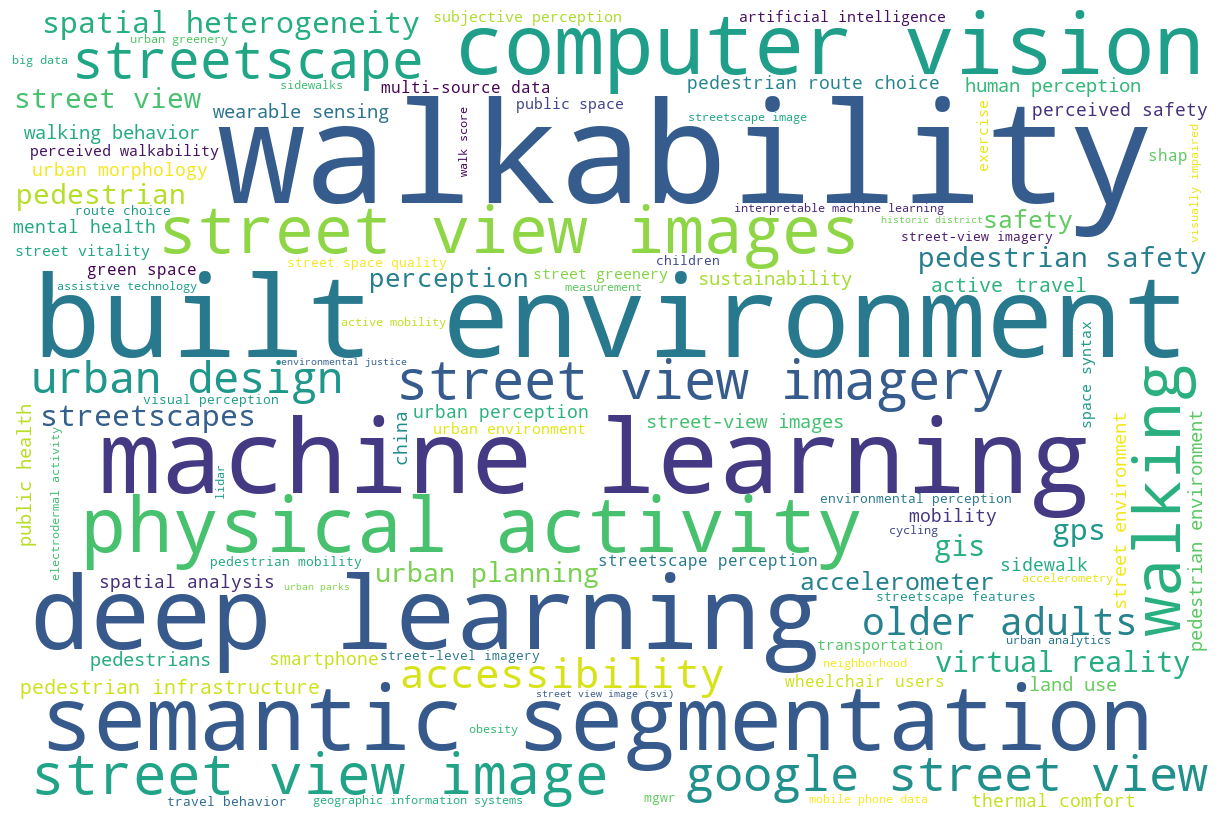

In [19]:
plt.figure(figsize=(12, 8))
wordcloud = WordCloud(
    width=1200,
    height=800,
    background_color="white",
    max_words=100,
    colormap="viridis",
    min_font_size=10,
).generate_from_frequencies(keyword_counts)

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

# 15. Keyword Co-occurrence and Correlation

In [20]:
unique_keywords = [kw for kw, _ in keyword_counts.most_common(40)]

doc_keyword_matrix = pd.DataFrame(0, index=range(len(keywords_by_doc)), columns=unique_keywords)
for pos, (doc_idx, kws) in enumerate(keywords_by_doc.items()):
    for kw in kws:
        if kw in unique_keywords:
            doc_keyword_matrix.loc[pos, kw] = 1

doc_keyword_matrix = doc_keyword_matrix.fillna(0).astype(int)

cooccurrence_matrix = doc_keyword_matrix.T.dot(doc_keyword_matrix)
np.fill_diagonal(cooccurrence_matrix.values, 0)

print("\nTop 10 co-occurring keyword pairs:")
cooccur_pairs = []
for kw1 in unique_keywords:
    for kw2 in unique_keywords:
        if kw1 < kw2:
            cooccur_pairs.append((kw1, kw2, cooccurrence_matrix.loc[kw1, kw2]))

cooccur_pairs.sort(key=lambda x: x[2], reverse=True)
for kw1, kw2, count in cooccur_pairs[:10]:
    print(f"{kw1} + {kw2}: {count:.0f} co-occurrences")


Top 10 co-occurring keyword pairs:
built environment + walkability: 20 co-occurrences
walkability + walking: 13 co-occurrences
built environment + physical activity: 13 co-occurrences
physical activity + walkability: 11 co-occurrences
built environment + machine learning: 10 co-occurrences
physical activity + walking: 10 co-occurrences
built environment + walking: 9 co-occurrences
deep learning + walkability: 9 co-occurrences
computer vision + machine learning: 9 co-occurrences
street view images + walkability: 8 co-occurrences


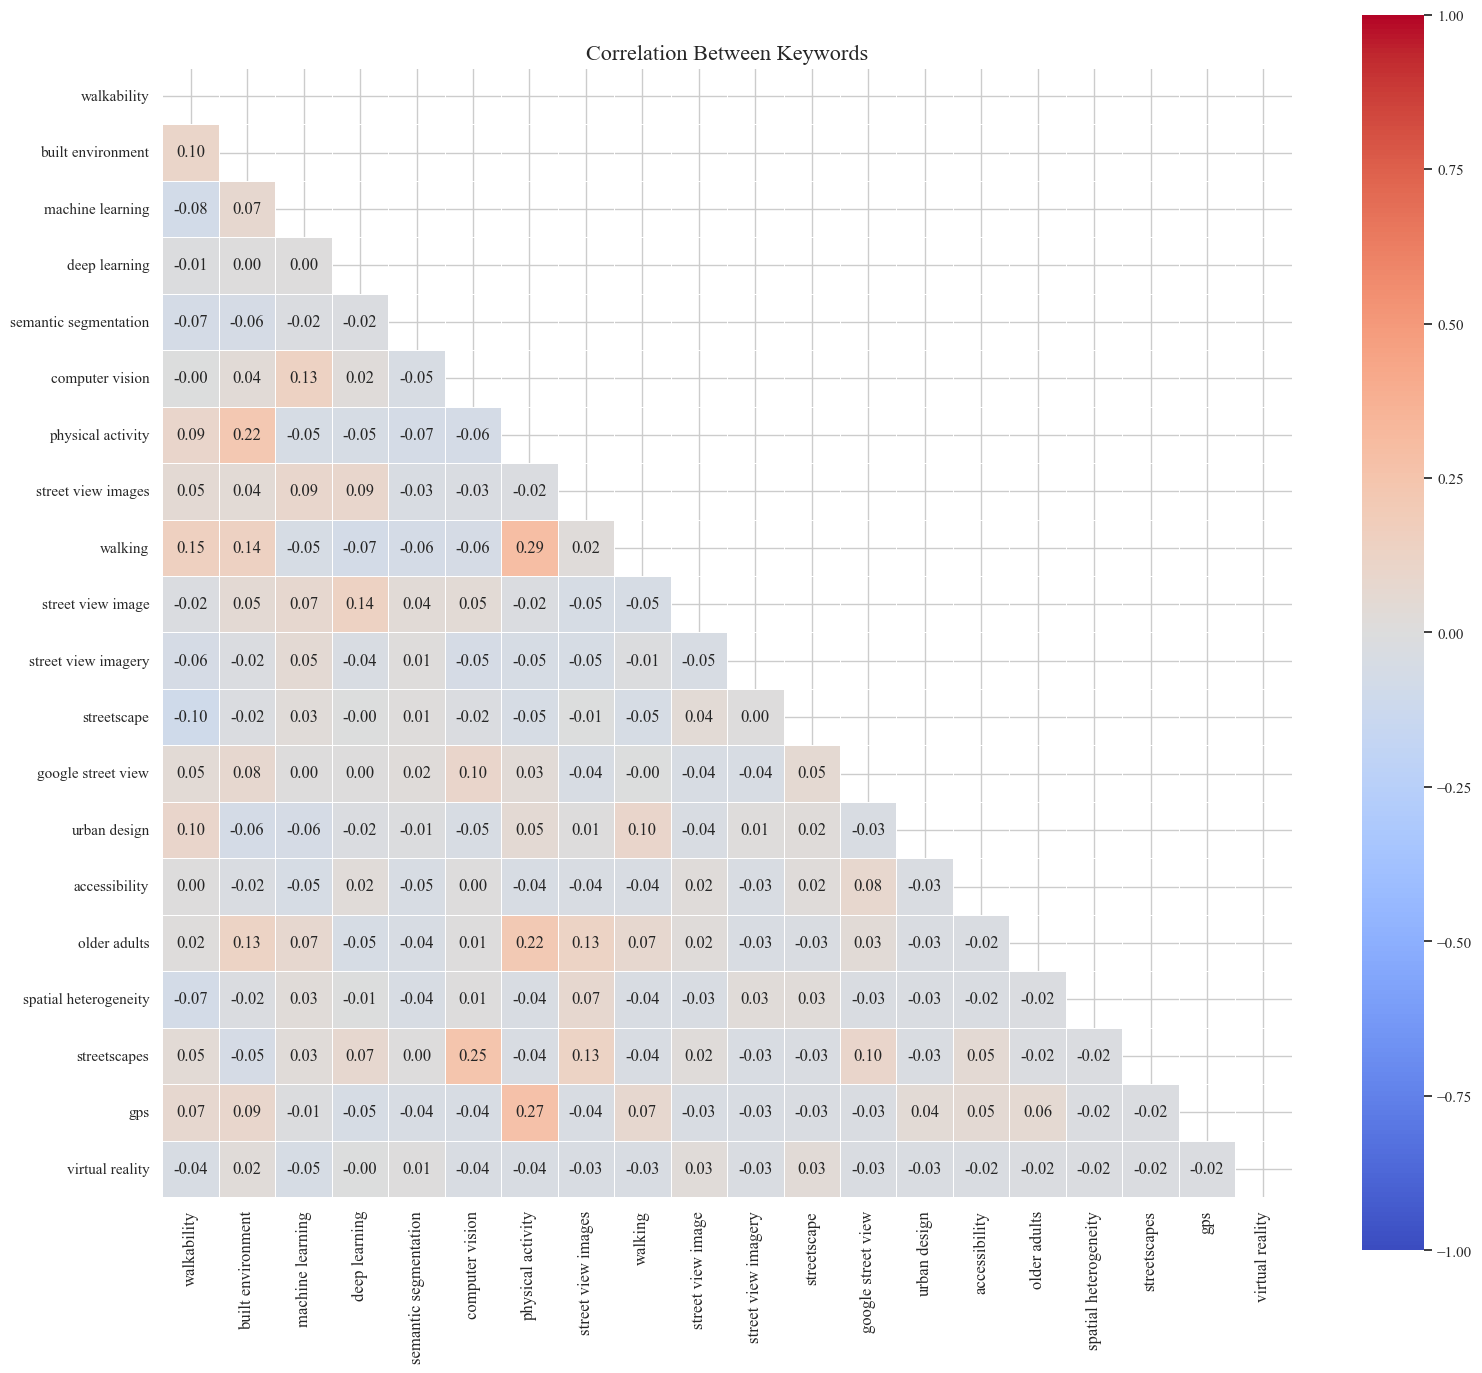

In [21]:
top20_keywords = [kw for kw, _ in keyword_counts.most_common(20)]
correlation_matrix = doc_keyword_matrix[top20_keywords].corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f",
    mask=mask, vmin=-1, vmax=1, square=True, linewidths=0.5,
)
plt.title("Correlation Between Keywords", fontsize=16)
plt.tight_layout()
plt.show()

# Geographic Distribution of Results

In [22]:
# Load original Scopus data with country information
import json
from collections import Counter

# Load Scopus data to extract country information
scopus_data = json.load(open('../data/01_scopus_results.json', encoding='utf-8'))

# Extract countries from each article
country_to_docs = {}
for idx, scopus_article in enumerate(scopus_data):
    if 'affiliation' in scopus_article and scopus_article['affiliation']:
        affiliations = scopus_article['affiliation']
        if not isinstance(affiliations, list):
            affiliations = [affiliations]
        
        countries = set()
        for aff in affiliations:
            if isinstance(aff, dict) and 'affiliation-country' in aff:
                countries.add(aff['affiliation-country'])
        
        for country in countries:
            if country not in country_to_docs:
                country_to_docs[country] = 0
            country_to_docs[country] += 1

# Sort by count
country_counts = sorted(country_to_docs.items(), key=lambda x: x[1], reverse=True)
print(f"Total countries: {len(country_counts)}")
print(f"\nTop 15 countries:")
for country, count in country_counts[:15]:
    print(f"{country}: {count}")

Total countries: 75

Top 15 countries:
China: 389
United States: 329
South Korea: 98
Japan: 77
Canada: 75
Hong Kong: 69
United Kingdom: 48
Australia: 46
Spain: 36
Germany: 23
India: 23
Singapore: 22
Taiwan: 20
Netherlands: 18
Italy: 18


In [23]:
# Install plotly if needed and create a choropleth map
try:
    import plotly.graph_objects as go
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'plotly'])
    import plotly.graph_objects as go

# Country name to ISO-3 code mapping (for plotly)
country_name_mapping = {
    'China': 'CHN',
    'United States': 'USA',
    'India': 'IND',
    'Brazil': 'BRA',
    'United Kingdom': 'GBR',
    'Germany': 'DEU',
    'France': 'FRA',
    'Japan': 'JPN',
    'South Korea': 'KOR',
    'Canada': 'CAN',
    'Australia': 'AUS',
    'Italy': 'ITA',
    'Spain': 'ESP',
    'Netherlands': 'NLD',
    'Singapore': 'SGP',
    'Taiwan': 'TWN',
    'Hong Kong': 'HKG',
    'Thailand': 'THA',
    'South Africa': 'ZAF',
    'Mexico': 'MEX',
    'Malaysia': 'MYS',
    'Indonesia': 'IDN',
    'Philippines': 'PHL',
    'Vietnam': 'VNM',
    'Viet Nam': 'VNM',  # Alternative name for Vietnam
    'Chile': 'CHL',
    'Argentina': 'ARG',
    'Colombia': 'COL',
    'Greece': 'GRC',
    'Portugal': 'PRT',
    'Sweden': 'SWE',
    'Norway': 'NOR',
    'Denmark': 'DNK',
    'Finland': 'FIN',
    'Belgium': 'BEL',
    'Switzerland': 'CHE',
    'Austria': 'AUT',
    'Poland': 'POL',
    'Czech Republic': 'CZE',
    'Russia': 'RUS',
    'Russian Federation': 'RUS',  # Alternative name for Russia
    'Turkey': 'TUR',
    'Israel': 'ISR',
    'Saudi Arabia': 'SAU',
    'UAE': 'ARE',
    'New Zealand': 'NZL',
    'Ireland': 'IRL',
    'Pakistan': 'PAK',
    'Bangladesh': 'BGD',
    'Egypt': 'EGY',
    'Nigeria': 'NGA',
    'Kenya': 'KEN',
    'Peru': 'PER',
    'Ecuador': 'ECU',
    'Bolivia': 'BOL',
    'Paraguay': 'PRY',
    'Uruguay': 'URY',
    'Costa Rica': 'CRI',
    'Panama': 'PAN',
    'Guatemala': 'GTM',
    'El Salvador': 'SLV',
    'Honduras': 'HND',
    'Nicaragua': 'NIC',
    'Dominican Republic': 'DOM',
    'Cuba': 'CUB',
    'Jamaica': 'JAM',
    'Trinidad and Tobago': 'TTO',
    'Bahamas': 'BHS',
    'Barbados': 'BRB',
    'Iran': 'IRN',
    'Macao': 'MAC',
    'Ghana': 'GHA',
    'Hungary': 'HUN',
    'Iraq': 'IRQ',
    'Uganda': 'UGA',
    'Algeria': 'DZA',
    'Slovakia': 'SVK',
    'Estonia': 'EST',
    'Romania': 'ROU',
    'Rwanda': 'RWA',
    'Lithuania': 'LTU',
    'Morocco': 'MAR',
    'Latvia': 'LVA',
    'Ukraine': 'UKR',
    'Cyprus': 'CYP',
    'Kuwait': 'KWT',
    'Ethiopia': 'ETH',
    'Bulgaria': 'BGR',
    'Sri Lanka': 'LKA',
    'Slovenia': 'SVN',
    'Croatia': 'HRV',
    'Kazakhstan': 'KAZ',
    'Tunisia': 'TUN',
    'Madagascar': 'MDG',
}

# Prepare data for mapping
countries_list = [c[0] for c in country_counts]
counts_list = [c[1] for c in country_counts]

# Create ISO code list
iso_codes = []
unmapped_countries = []
for country in countries_list:
    if country in country_name_mapping:
        iso_codes.append(country_name_mapping[country])
    else:
        unmapped_countries.append(country)
        iso_codes.append(None)

if unmapped_countries:
    print(f"Countries not in mapping: {unmapped_countries}")

# Filter out None values
filtered_countries = []
filtered_counts = []
filtered_iso = []
for c, cnt, iso in zip(countries_list, counts_list, iso_codes):
    if iso:
        filtered_countries.append(c)
        filtered_counts.append(cnt)
        filtered_iso.append(iso)

print(f"\nMapped {len(filtered_iso)} countries to ISO codes")

Countries not in mapping: [None]

Mapped 74 countries to ISO codes


In [24]:
# Create choropleth map
fig = go.Figure(data=go.Choropleth(
    locations = filtered_iso,
    z = filtered_counts,
    text = filtered_countries,
    colorscale = 'Viridis',
    autocolorscale=False,
    reversescale=False,
    marker_line_color='darkgray',
    marker_line_width=0.5,
    colorbar_ticksuffix = ' articles',
    colorbar_title = 'Number of Articles',
    hovertemplate = '<b>%{text}</b><br>Articles: %{z}<extra></extra>'
))

fig.update_layout(
    title_text='Geographic Distribution of Smart City Research<br>(Sensor Dimensions & Walkability)',
    title_x=0.5,
    geo=dict(
        showland = True,
        landcolor = 'rgb(243, 243, 243)',
        coastlinecolor = 'rgb(204, 204, 204)',
        projection_type = 'natural earth',
        showocean = True,
        oceancolor = 'rgb(230, 245, 255)',
        showcountries = True,
        countrycolor = 'rgb(204, 204, 204)',
    ),
    height=600,
    width=1200,
    font=dict(family='Times New Roman', size=12)
)

fig.show()

print(f"\nTotal articles analyzed: {sum(filtered_counts)}")
print(f"Number of countries represented: {len(filtered_iso)}")


Total articles analyzed: 1532
Number of countries represented: 74


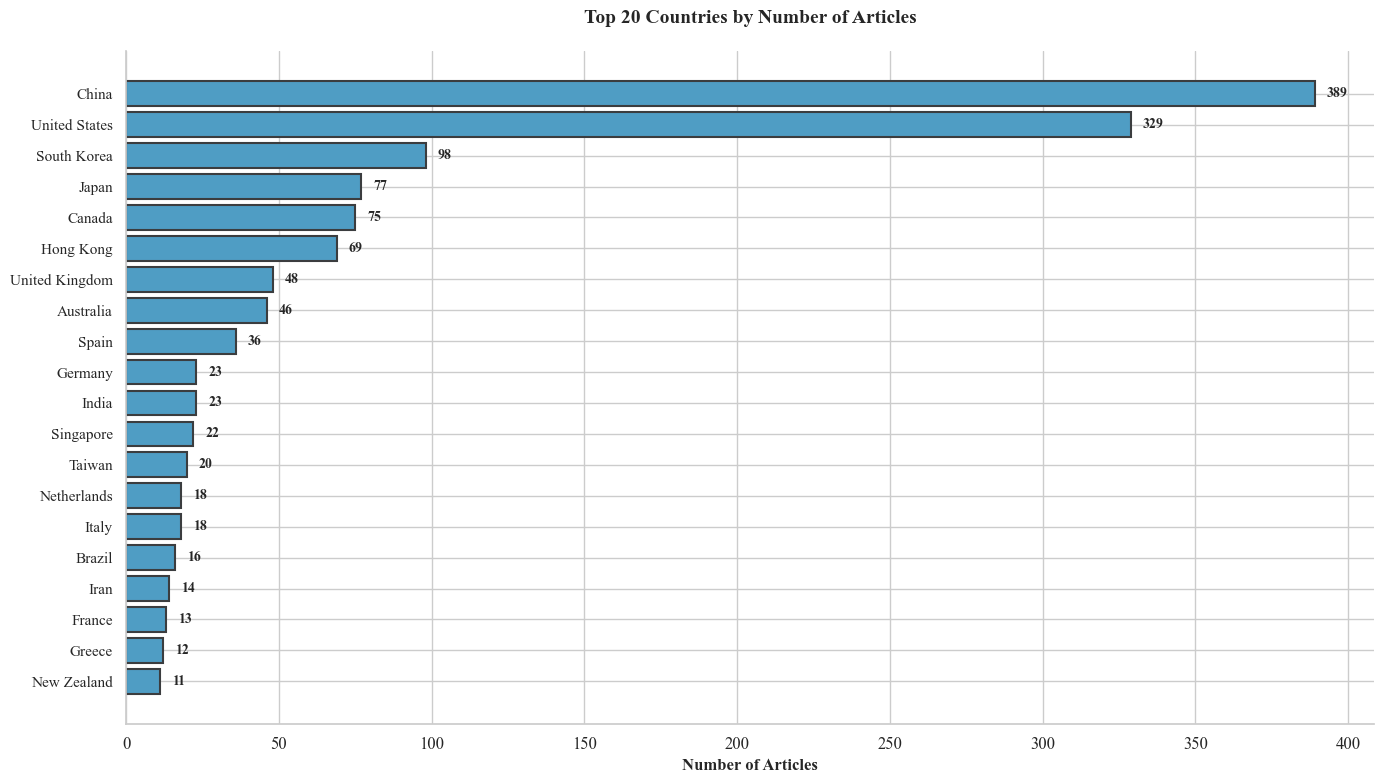


Country Distribution Summary:
Median articles per country: 4.0
Mean articles per country: 20.4
Std dev: 59.4


In [25]:
# Create a bar chart of top countries
fig, ax = plt.subplots(figsize=(14, 8))

top_n = 20
top_countries = sorted(country_to_docs.items(), key=lambda x: x[1], reverse=True)[:top_n]
countries_names = [c[0] for c in top_countries]
counts = [c[1] for c in top_countries]

bars = ax.barh(countries_names, counts, color=MATTE_COLORS['blue'], edgecolor=MATTE_COLORS['navy'], linewidth=1.5)

# Add value labels
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(count + max(counts) * 0.01, i, str(count), va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Number of Articles', fontsize=12, fontweight='bold')
ax.set_title(f'Top {top_n} Countries by Number of Articles', fontsize=14, fontweight='bold', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nCountry Distribution Summary:")
print(f"Median articles per country: {np.median(list(country_to_docs.values())):.1f}")
print(f"Mean articles per country: {np.mean(list(country_to_docs.values())):.1f}")
print(f"Std dev: {np.std(list(country_to_docs.values())):.1f}")